In [2]:
from lib import epl
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import matplotlib.pyplot as plt
%matplotlib inline

#Load Data
#rf = open('./data/singleOdorData.pi', 'r');
#trainingOdors = np.array(pickle.load(rf));
#testOdors = np.array(pickle.load(rf));
#rf.close();

trainingOdors, testOdors = np.load('singleOdorTest.npy', fix_imports=True, allow_pickle=True) 
print("Number of odors to train = " + str(len(trainingOdors)))
print("Number of odors to test = " + str(len(testOdors)))
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  


#Network initialization
nMCs = len(trainingOdors[0])
GCsPerNeurogenesis = 5
nGCs = int(nMCs*GCsPerNeurogenesis*nOdors) 
#every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis)


Number of odors to train = 1
Number of odors to test = 10


In [2]:

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1);
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);






Training odor 1


10 odors tested


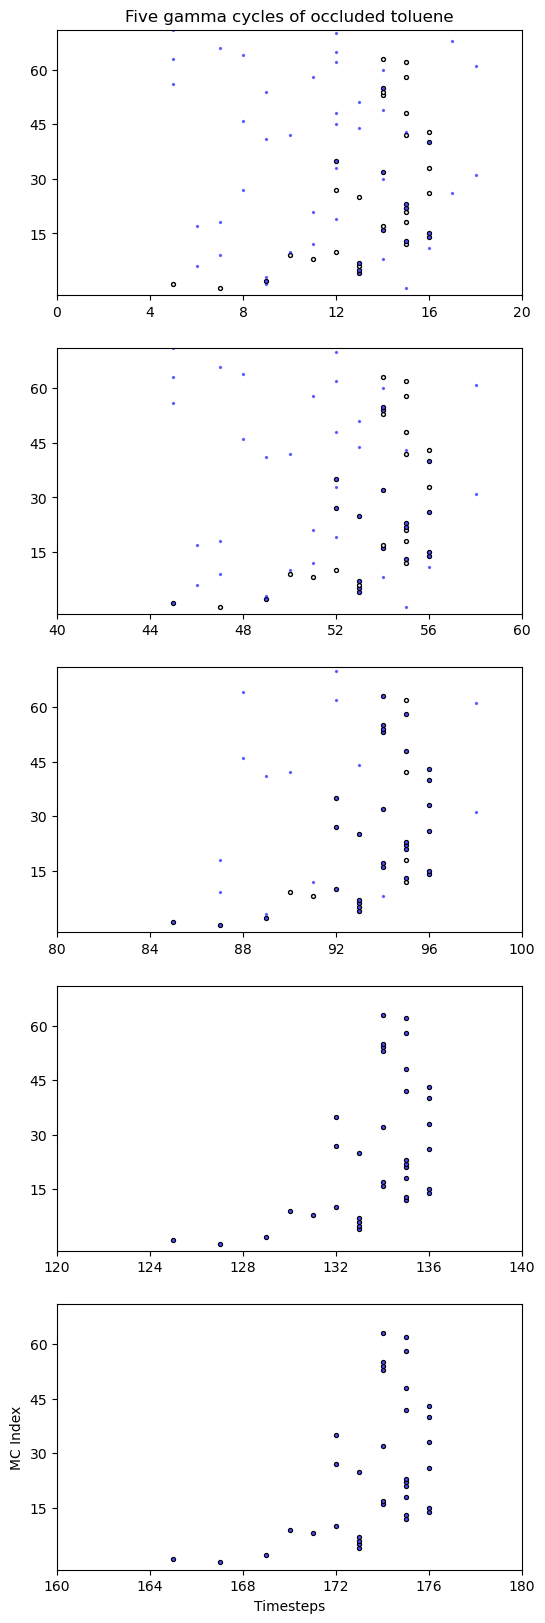

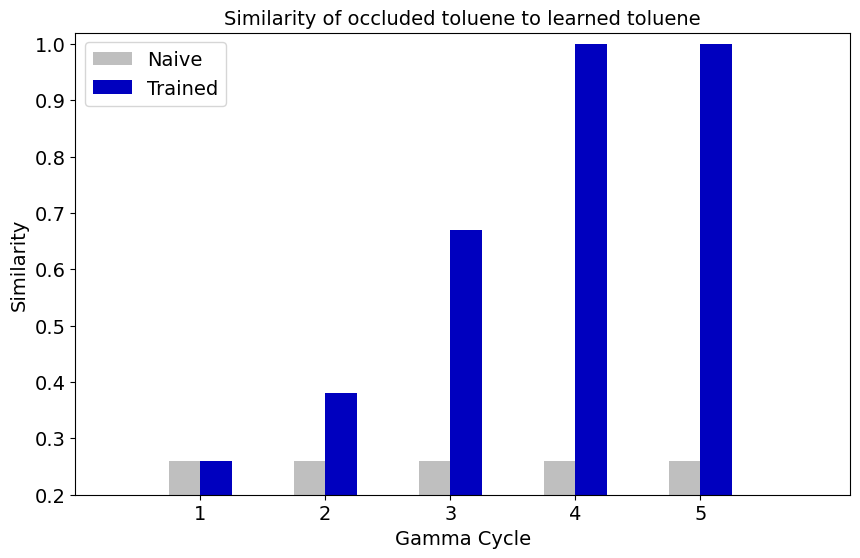

In [3]:
#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i==len(testOdors)-1):
        print(str(i+1) + " odors tested"); 
#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  

#Plots
plots.plotFigure3b(epl.gammaCode); 
plots.plotFigure3d(sMatrix); 

In [4]:
sMatrix

[[0.26],
 [0.38],
 [0.67],
 [1.0],
 [1.0],
 [0.3],
 [0.66],
 [1.0],
 [1.0],
 [1.0],
 [0.3],
 [0.8],
 [1.0],
 [1.0],
 [1.0],
 [0.29],
 [0.41],
 [0.62],
 [0.87],
 [1.0],
 [0.29],
 [0.52],
 [1.0],
 [1.0],
 [1.0],
 [0.27],
 [0.44],
 [0.71],
 [1.0],
 [1.0],
 [0.26],
 [0.45],
 [0.58],
 [0.8],
 [1.0],
 [0.31],
 [0.36],
 [0.37],
 [0.37],
 [0.37],
 [0.26],
 [0.47],
 [0.89],
 [1.0],
 [1.0],
 [0.25],
 [0.25],
 [0.25],
 [0.25],
 [0.25]]

In [5]:
trainingOdors.shape


(1, 72)

In [6]:
testOdors.shape

(10, 72)

In [7]:
trainingOdors

array([[13, 15, 11,  0,  7,  7,  7,  7,  9, 10,  8,  0,  5,  5,  4,  4,
         6,  6,  5,  0,  0,  5,  5,  5,  0,  7,  4,  8,  0,  0,  0,  0,
         6,  4,  0,  8,  0,  0,  0,  0,  4,  0,  5,  4,  0,  0,  0,  0,
         5,  0,  0,  0,  0,  6,  6,  6,  0,  0,  5,  0,  0,  0,  5,  6,
         0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [8]:
len(epl.gammaCode)

60